# Explanatory data analysis On vendor sales summary

- Previously we examined the various tables in the database to identify the key variables understand the relationships and determine which ones should be included in the final analysis
- In this phase of EDA We will analyse the resultant table to gain insults into the distribution of each column This will help us understand data patterns identify anomalies and ensure data quality before proceeding with further analysis

In [159]:
# import all the libararies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#load the dataset 

In [160]:
df = pd.read_csv('vendor_sales_summary.csv')

In [161]:
df.head()

,VendorName,VendorNumber,Brand,Description,PurchasePrice,ActualPrice,Volume,total_quantity,total_dollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,profitMargin,Stockturnover,SalesPurchaseration
0,BROWN-FORMAN CORP,1128,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,MARTIGNETTI COMPANIES,4425,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,PERNOD RICARD USA,17035,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,DIAGEO NORTH AMERICA INC,3960,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,DIAGEO NORTH AMERICA INC,3960,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [162]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
total_quantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
total_dollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05


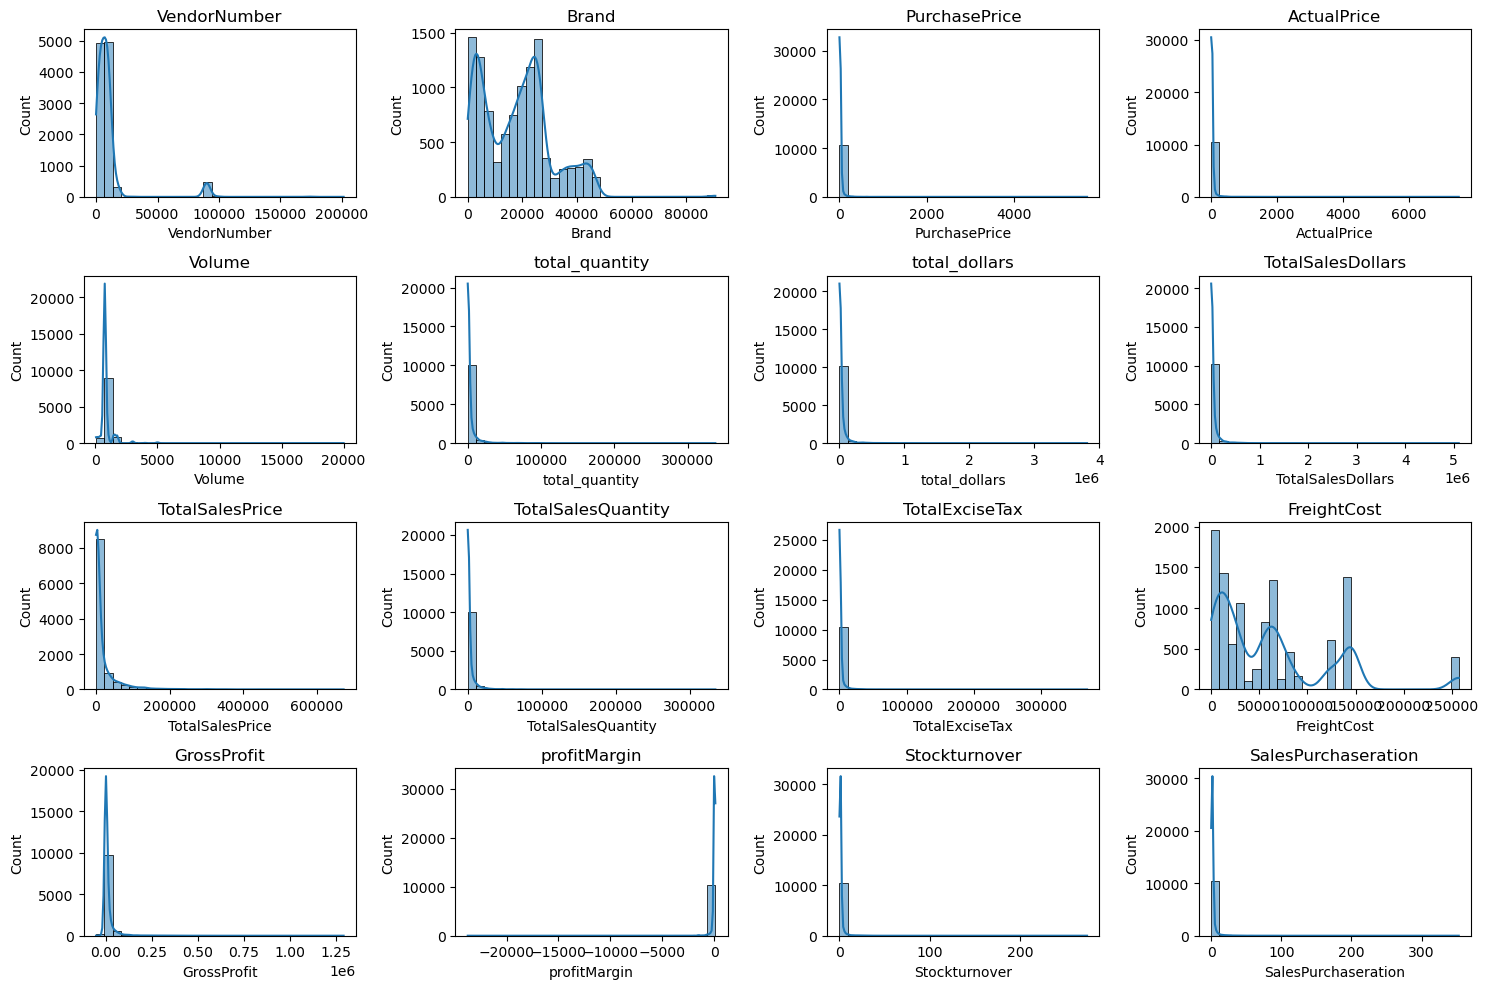

In [163]:
# Distributing the plots for the numerical columns 
numerical_columns  = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_columns):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

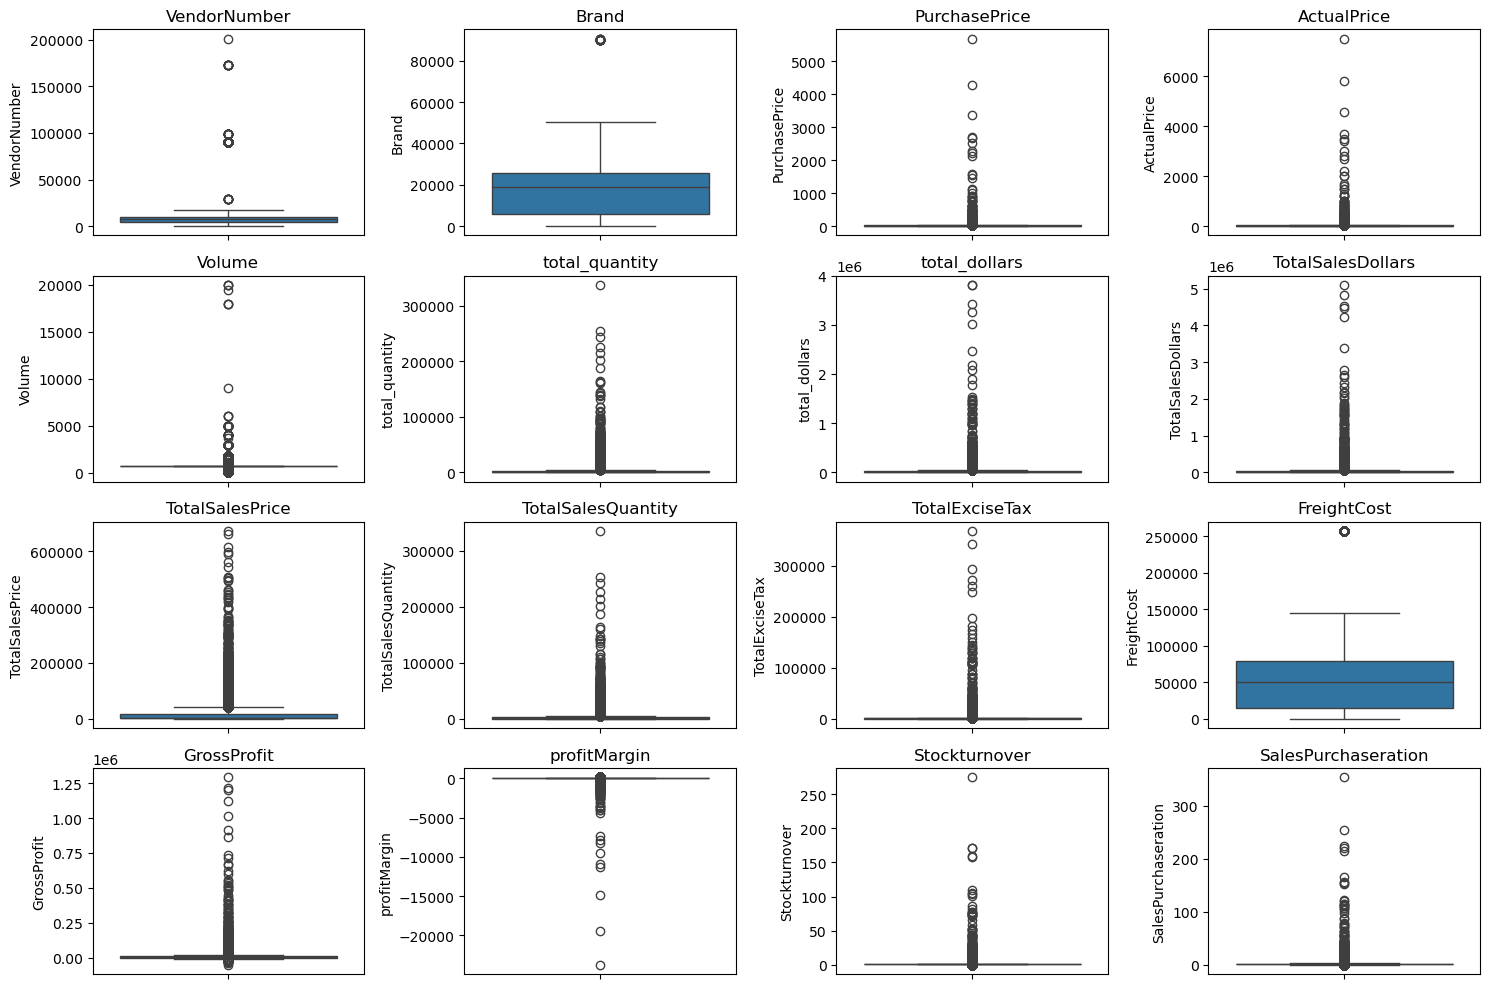

In [164]:

numerical_columns  = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_columns):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [165]:
df['Unsoldinventoryvalue'] = (df['total_quantity']-df['TotalSalesQuantity']) * df['PurchasePrice']

## Summary statistics insights

##### Negatives and zero values
 - Gross profit has a minimum of about −52,002.78, indicating some products or
   transactions are sold at a loss, likely due to high costs or strong discounting.
 - Profit margin reaches negative infinity, which points to cases where revenue
   is zero or lower than cost, meaning these items never generated sales or
   were heavily discounted.
 - Total sales quantity and total sales dollars have minimum values of 0,
   showing some products were purchased but never sold, suggesting slow‑moving
   or obsolete inventory.

##### Outliers and high variability
 - Purchase price and actual selling price have very high maximums (around
   5,681.81 and 7,499.99) relative to their means, indicating a small set of
   premium or niche products priced far above the core range.
 - Freight cost ranges from 0.09 to 257,032.07, revealing extreme variation in
   logistics costs that may stem from bulk shipments, long‑distance suppliers,
   or inefficient freight allocation.
 - Stock turnover ranges from 0 to 274.5, meaning some products barely move
   while others sell extremely fast; values above 1 imply sales are drawing
   on older inventory or prior purchase cycles rather than only current‑period
   purchases.


In [166]:
# Let's philtre the data by removing inconsistency
mask = (
    (df['GrossProfit'] > 0) &
    (df['profitMargin'] > 0) &
    (df['TotalSalesQuantity'] > 0)
)

df_new = df[mask]          # full table, all columns matching the condition


In [167]:
df_new.shape

(8564, 19)

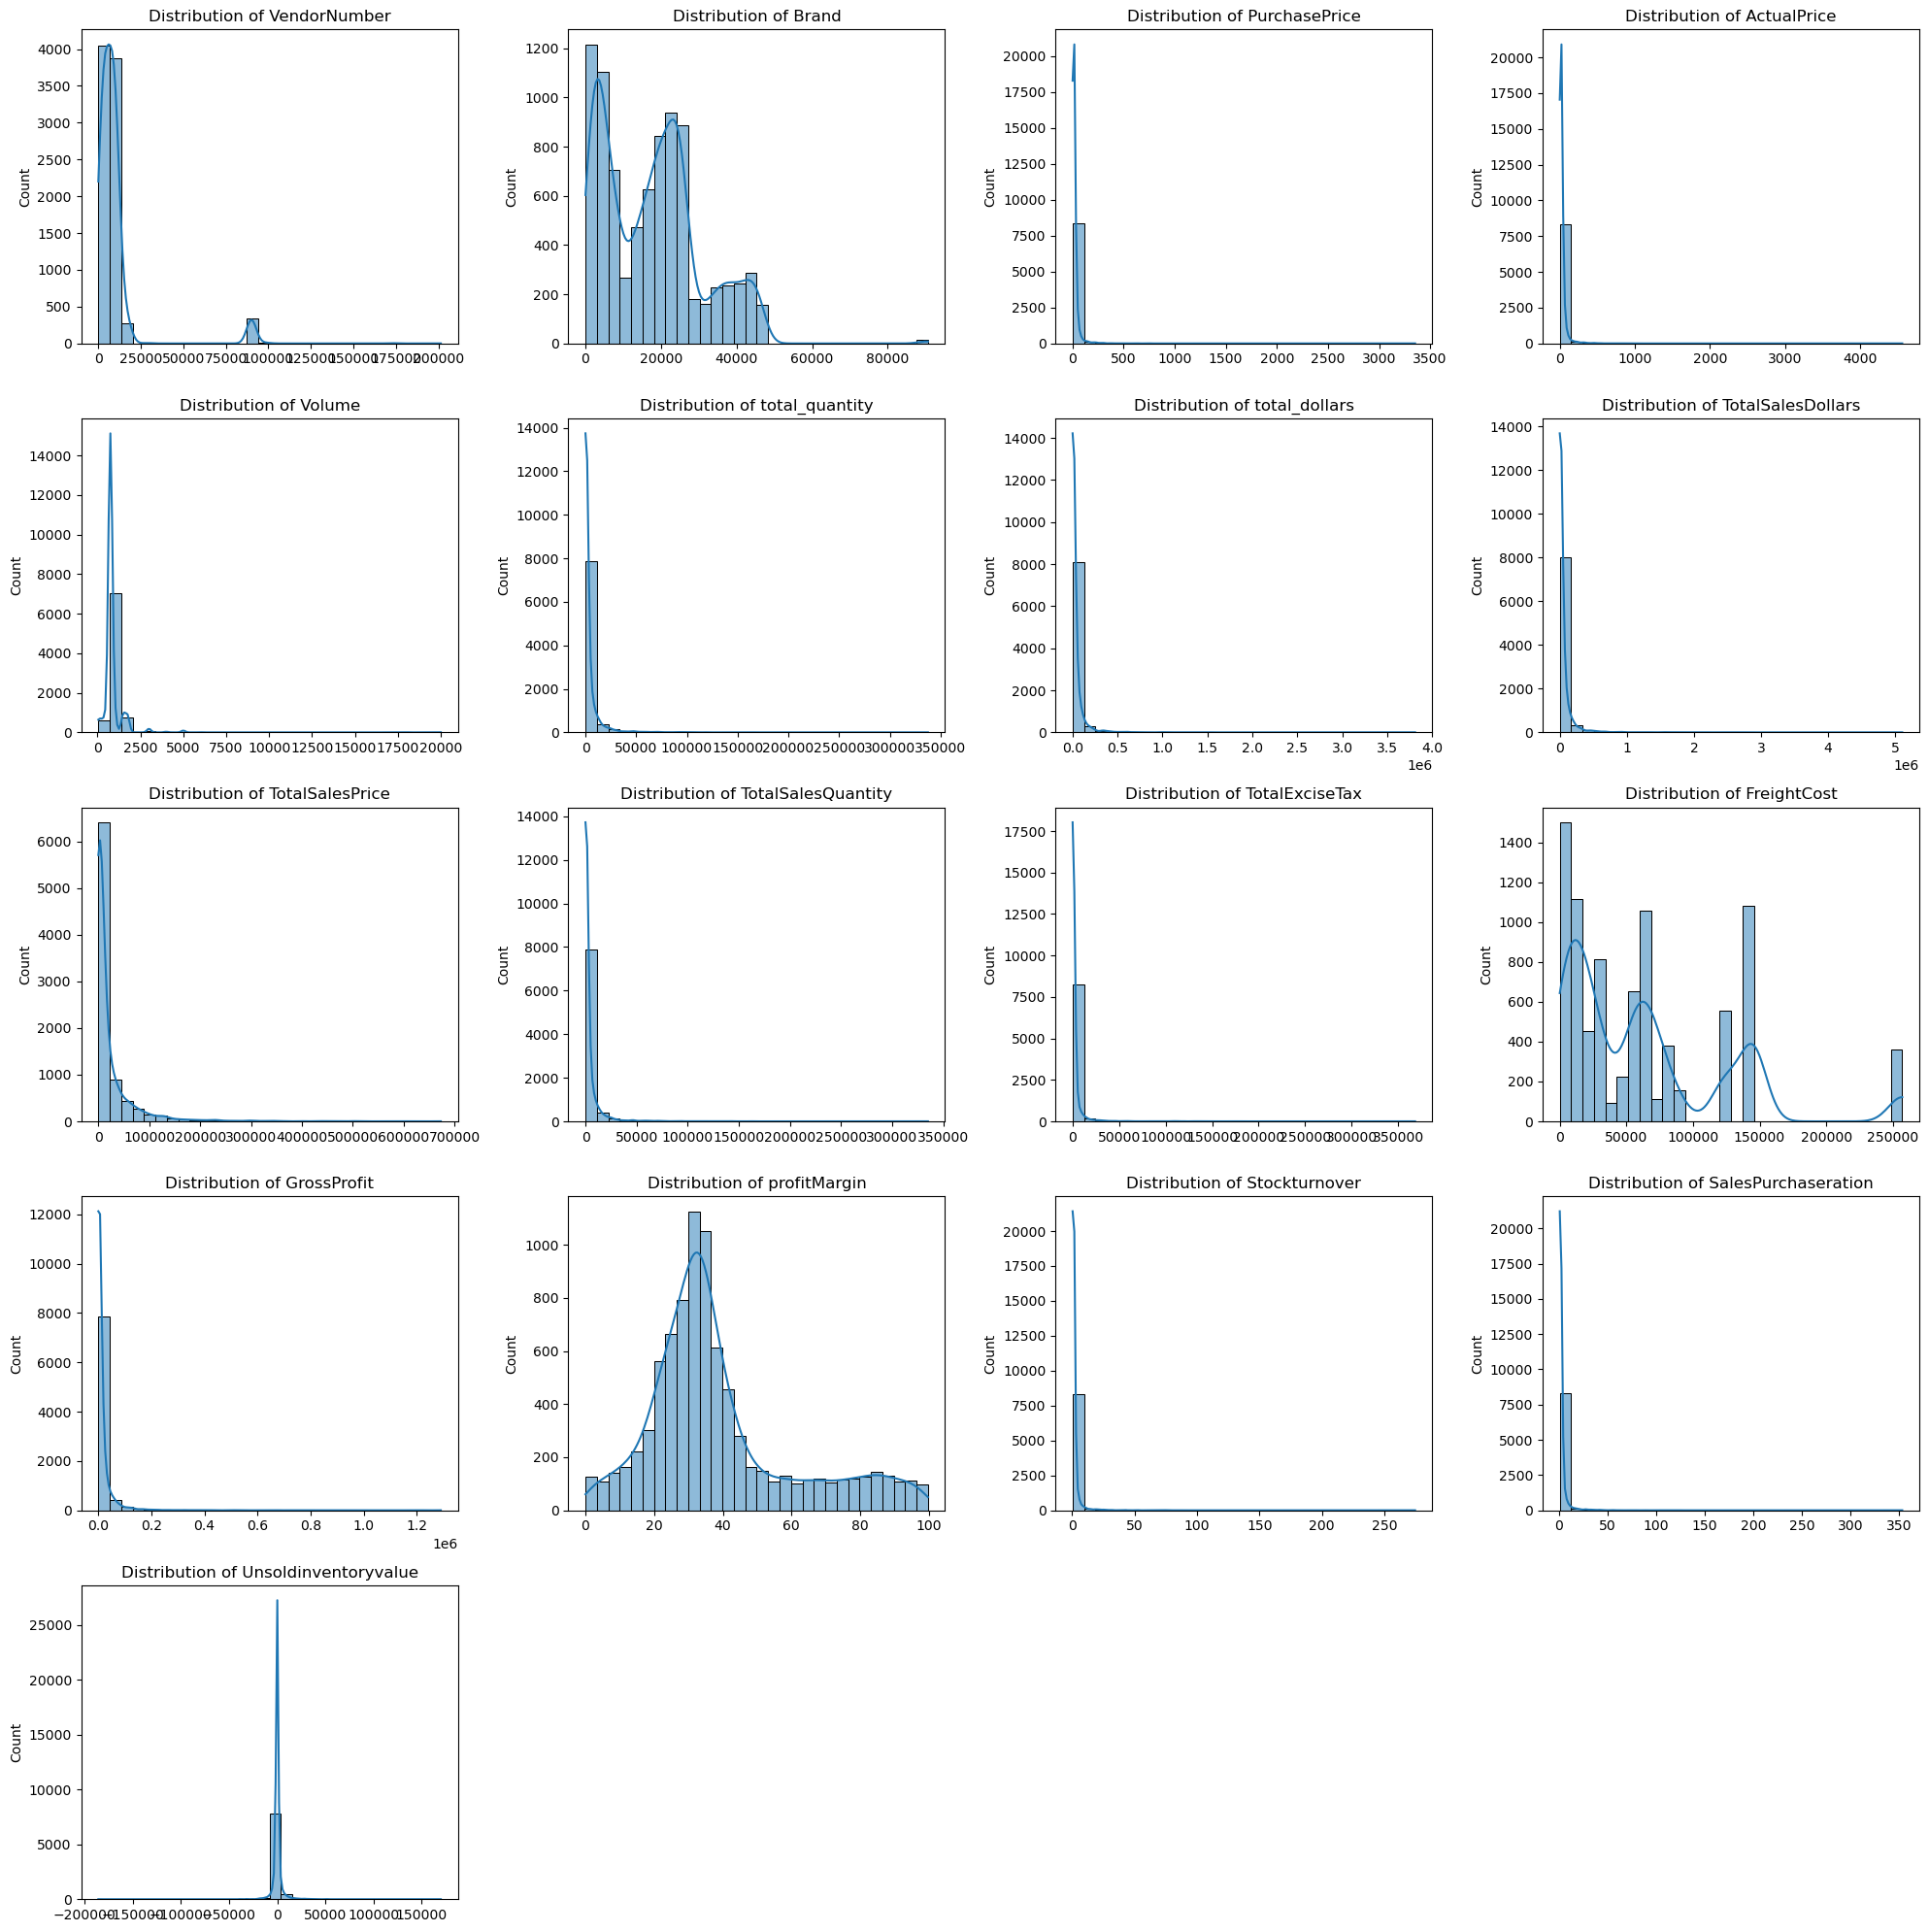

In [168]:
# Distributing the plots for the numerical columns 
import math

numerical_columns = df_new.select_dtypes(include=np.number).columns
n_cols = len(numerical_columns)

# Calculate grid size (we'll stick to 4 columns wide, and calculate rows needed)
cols_per_row = 4
rows = math.ceil(n_cols / cols_per_row)

plt.figure(figsize=(20, rows * 4)) # Adjust height based on number of rows

for i, col in enumerate(numerical_columns):
    plt.subplot(rows, cols_per_row, i + 1) 
    sns.histplot(df_new[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel("") # Keeps it cleaner

plt.tight_layout()
plt.show()

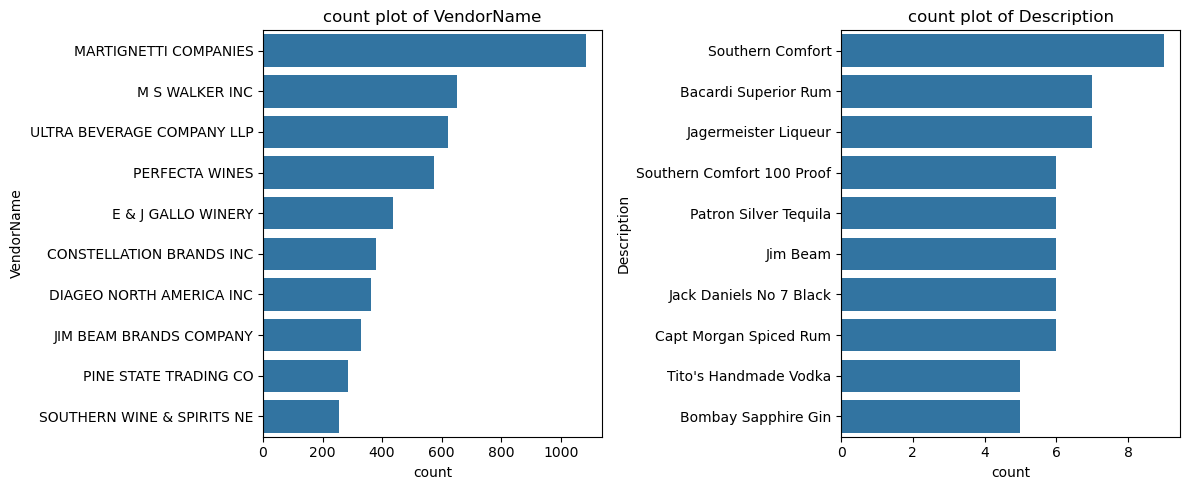

In [169]:
# Count plots for categorical data 

categorical_columns  = ["VendorName","Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_columns):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df_new[col], order=df_new[col].value_counts().index[:10])
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

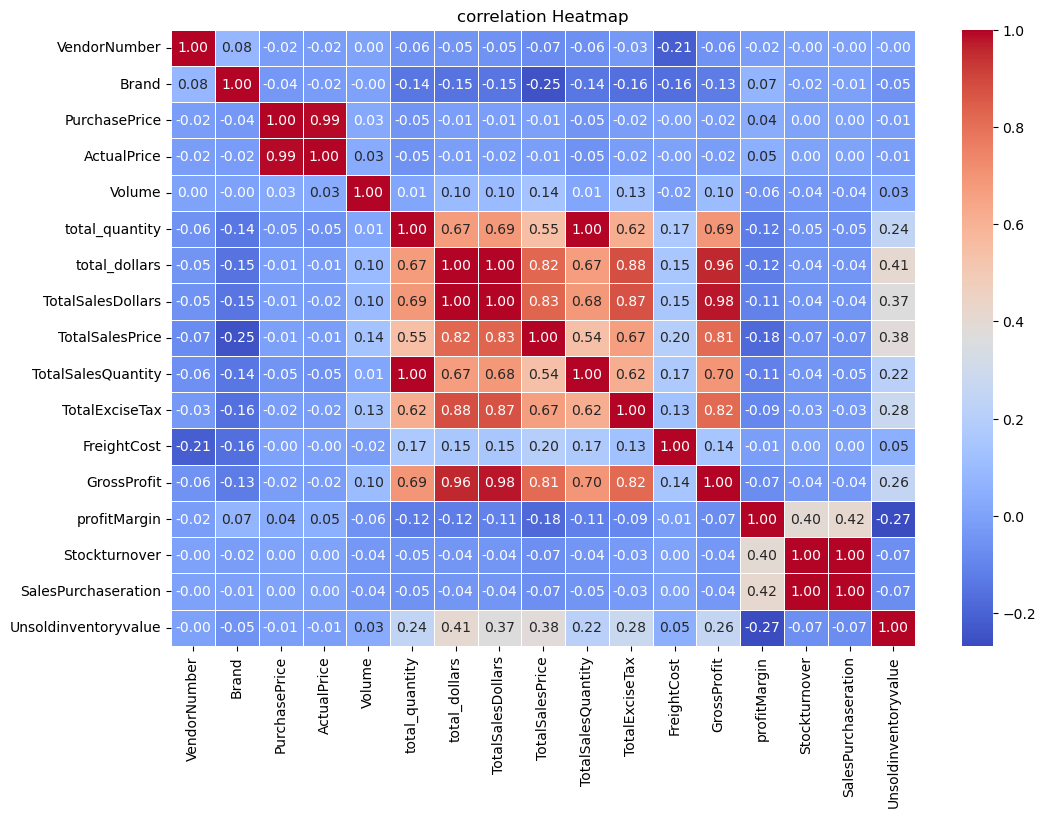

In [170]:
#correlation heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df_new[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("correlation Heatmap")
plt.show()


### Correlation insights
- Purchase price has a weak correlation with the total sales dollars And gross profit Suggesting that the price variation do not significantly impact sales revenue or profit
- Strong correlation between total purchase quantity and total sales quantity confirming efficient inventory turnover.
- Negative correlation between profit Margin And total sales price Suggest that that as sales price increases margin decreases possibly due to competitive price impression
- Stock turnover has a weak negative correlation with both gross profit and profit margin Indicating that faster than our does not necessarily result in higher profitability

### Data Analysis 

Identify the brands that need promotional or pricing adjustment which exhibits lower sales performance but higher profit margins

In [171]:
brand_performance = df_new.groupby('Description').agg({'TotalSalesDollars':'sum','profitMargin':'mean'})

low_sales_thershold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_thershold = brand_performance['profitMargin'].quantile(0.80)

print(low_sales_thershold)

print(high_margin_thershold)

target_brand = brand_performance[

    (brand_performance['TotalSalesDollars'] <= low_sales_thershold) &
    (brand_performance['profitMargin'] >= high_margin_thershold)
]

# This line is only written So that we can get a better visualisation of which brands Need Pricing Adjustments or promotional
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000]
print(target_brand.sort_values('TotalSalesDollars'))



560.299
53.569222709109354
                              TotalSalesDollars  profitMargin
Description                                                  
Santa Rita Organic Svgn Bl                 9.99     66.466466
Debauchery Pnt Nr                         11.58     65.975820
Concannon Glen Ellen Wh Zin               15.95     83.448276
Crown Royal Apple                         27.86     89.806174
Sauza Sprklg Wild Berry Marg              27.96     82.153076
...                                         ...           ...
Sbragia Home Ranch Merlot                549.75     66.444748
Smirnoff Fluffed Marshmallow             554.63     61.392280
Vino.e Falanghina Beneventno             558.57     63.352847
Goulee Cos d'Estournel 10                558.87     69.434752
Atlas Peak Cab Svgn                      559.84     60.803087

[261 rows x 2 columns]


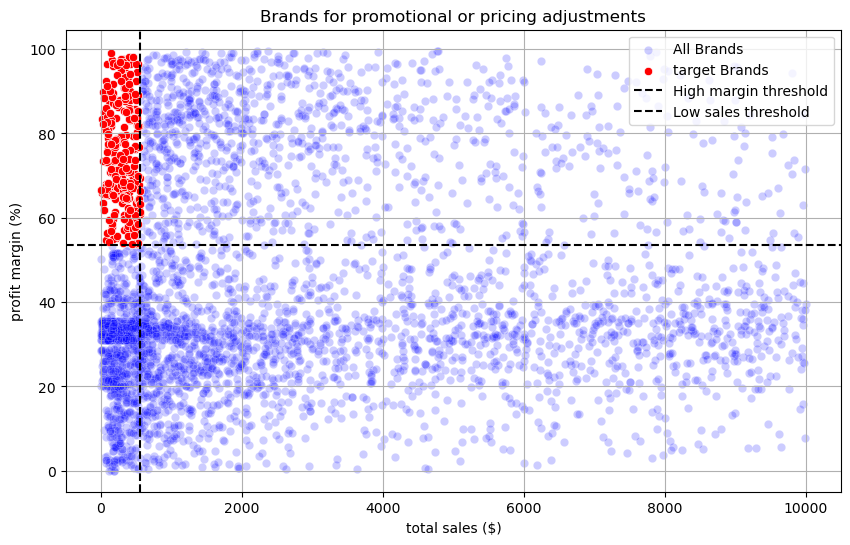

In [172]:
plt.figure(figsize=(10, 6))

# all brands faintly in blue
sns.scatterplot(data=brand_performance,
                x='TotalSalesDollars', y='profitMargin',
                color='blue', label="All Brands", alpha=0.2)

# highlight the target ones
sns.scatterplot(data=target_brand,
                x='TotalSalesDollars', y='profitMargin',
                color='red', label="target Brands")

plt.axhline(high_margin_thershold, linestyle='--', color='black',
            label="High margin threshold")
plt.axvline(low_sales_thershold, linestyle='--', color='black',
            label="Low sales threshold")

plt.xlabel("total sales ($)")
plt.ylabel("profit margin (%)")
plt.title("Brands for promotional or pricing adjustments")
plt.legend()
plt.grid(True)
plt.show()


Which brands and vendors demonstrate the highest sales performance

In [173]:

top_vendors = df_new.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df_new.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors


VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [174]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [175]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [176]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

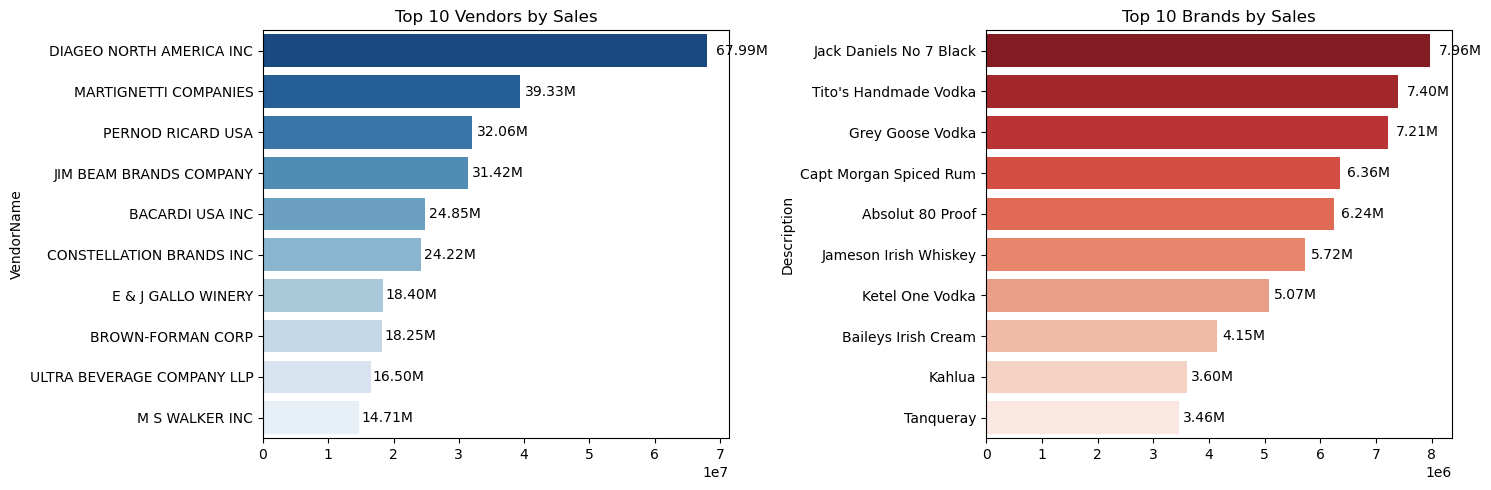

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    hue=top_vendors.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    hue=top_brands.index.astype(str),
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

which vendors contribute the most to total purchase dollars?

In [178]:
vendor_Contribution = df_new.groupby('VendorName').agg({
    'total_dollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_Contribution.shape

(119, 4)

In [179]:
vendor_Contribution['purchasecontribution'] = vendor_Contribution['total_dollars']/vendor_Contribution['total_dollars'].sum()*100

# purchasecontribution = vendor's totalpurchasedollors / total number of totalpurchasedollors

vendor_Contribution_performance = round(vendor_Contribution.sort_values('purchasecontribution',ascending=False),2)

In [180]:
top_vendors = vendor_Contribution_performance.head(10).copy()

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['total_dollars'] = top_vendors['total_dollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors


,VendorName,total_dollars,GrossProfit,TotalSalesDollars,purchasecontribution
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [181]:
top_vendors['purchasecontribution'].sum()

np.float64(65.69000000000001)

In [182]:
top_vendors['Cumulativecontribution'] = top_vendors['purchasecontribution'].cumsum()
top_vendors

,VendorName,total_dollars,GrossProfit,TotalSalesDollars,purchasecontribution,Cumulativecontribution
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


How much of total Procurement is dependent on the top 10 vendors ?

In [183]:
print(" The total purchase contribution of top 10 vendors is")
print(f"{round(top_vendors['purchasecontribution'].sum(),2)} %")

 The total purchase contribution of top 10 vendors is
65.69 %


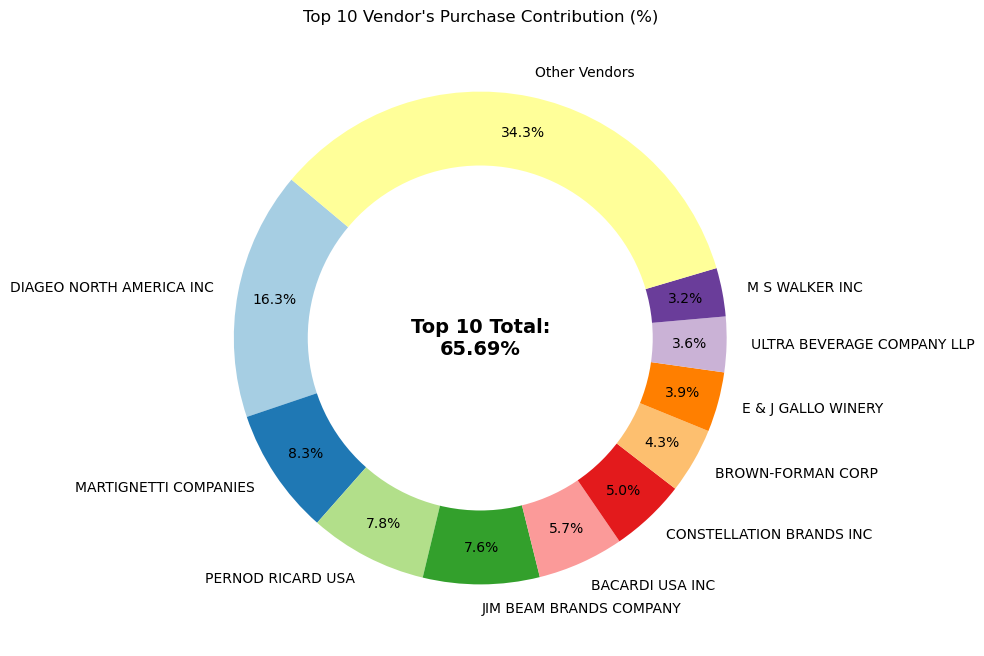

In [184]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['purchasecontribution'].values)
total_contributions = sum(purchase_contributions)
remaining_contributions = 100 - total_contributions



# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contributions)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)


# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contributions:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Which vendors have low inventory turnover indicating excess stock and slow moving products

In [196]:
df_new[df_new['Stockturnover']<1].groupby('VendorName')[['Stockturnover']].mean().sort_values('Stockturnover',ascending=True).head(10)

,Stockturnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


how much capital is locked  in unsold inventory per vendor and which vendors contribute the most to it?

In [186]:
format_dollars(df_new['Unsoldinventoryvalue'].sum())

'2.71M'

In [187]:
inventory_value_per_vendor = df_new.groupby('VendorName')['Unsoldinventoryvalue'].sum().reset_index()


inventory_value_per_vendor  = inventory_value_per_vendor.sort_values('Unsoldinventoryvalue',ascending=False)
inventory_value_per_vendor['Unsoldinventoryvalue'] = inventory_value_per_vendor['Unsoldinventoryvalue'].apply(format_dollars)
inventory_value_per_vendor.head(10)


,VendorName,Unsoldinventoryvalue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


What is 95% confidence interval for profit margins of top performings and low performing vendors

In [188]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def confidence_interval(data, confidence=0.95):
    # Ensure data is a numpy array to avoid issues with pandas series
    data = np.array(data)
    mean_val = np.mean(data)
    # Standard Error of the Mean (SEM)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) 
    
    # FIX: changed df_new to df (the correct scipy parameter)
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1) 
    
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [189]:
top_threshold = df_new['TotalSalesDollars'].quantile(0.75)
low_threshold = df_new['TotalSalesDollars'].quantile(0.25)

In [190]:
top_vendors = df_new[df_new['TotalSalesDollars'] >= top_threshold]['profitMargin'].dropna()
low_vendors = df_new[df_new['TotalSalesDollars'] <= low_threshold]['profitMargin'].dropna()


Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


Text(0.5, 0, 'Profit Margin (%)')

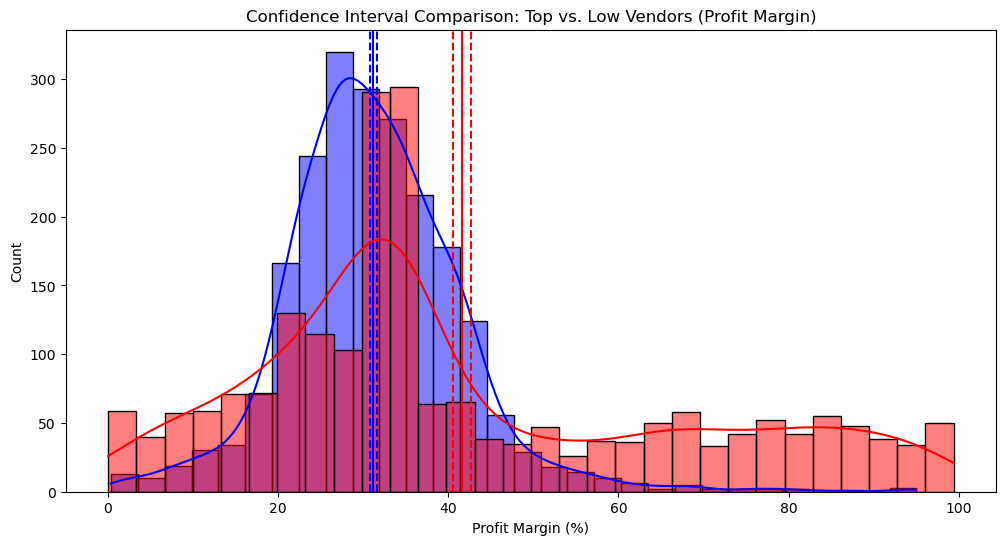

In [191]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")

- This suggests that the vendors with lower sales trend Maintain higher profit margin potentially due to the premium pricing or low operational costs
- For high performance vendor if they aim to improve profitability they could explore more selective price adjustments cost optimization or bonding strategies
- For the low performance vendor Despite higher margins Their low sales volume might indicate A need for Better marketing or Pricing adjustments are Improved distributions Or promoting their products In a better way 

**Is there a significant difference in profit margins between top performing and low performing vendors**

Hypothesis :

H0 (Null hypothesis) : There is no significant difference in the mean profit margins of top performing and do performing vendors

H1 (Alternative hypothesis) : The main profit margins of top performing and low performing vendors are significantly different

In [192]:
import scipy.stats as stats

top_threshold = df_new['TotalSalesDollars'].quantile(0.75)
low_threshold = df_new['TotalSalesDollars'].quantile(0.25)
top_vendors = df_new[df_new['TotalSalesDollars'] >= top_threshold]['profitMargin'].dropna()
low_vendors = df_new[df_new['TotalSalesDollars'] <= low_threshold]['profitMargin'].dropna()

# 3. Performing the T-test (FIXED: Changed 'testing' to 'stats.ttest_ind')
# equal_var=False performs Welch's T-test, which is safer for groups of different sizes
t_stat, p_value = stats.ttest_ind(top_vendors, low_vendors, equal_var=False) 


print(f"t-Statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}") 

print("-" * 30)


# 4. Hypothesis Testing Logic
if p_value < 0.05:
    print("Conclusion: There is a SIGNIFICANT difference in profit margins between top and low performing vendors.")
    print("Decision: Rejecting H0 (Null Hypothesis)")
else:
    print("Conclusion: No significant difference in profit margins found.")
    print("Decision: Failed to reject H0.")

t-Statistic: -17.6695
p-value: 2.2969e-66
------------------------------
Conclusion: There is a SIGNIFICANT difference in profit margins between top and low performing vendors.
Decision: Rejecting H0 (Null Hypothesis)


In [193]:
df_new.to_excel("df_new.xlsx", index=False)